#### Using Proto-ML [1] to analyse the drug reviews dataset [2]

[1] https://github.com/yx131/proto-lm/tree/main

[2] https://www.kaggle.com/datasets/mohamedabdelwahabali/drugreview/data

### Global imports

In [1]:
import argparse

import torch
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification


from ProtoLM import proto_lm
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers.tensorboard import TensorBoardLogger

import datasets

### Drug Review Data Class

In [2]:
class sst_datamodule(pl.LightningDataModule):
    loader_columns = [
        "datasets_idx",
        "input_ids",
        "token_type_ids",
        "attention_mask",
        "start_positions",
        "end_positions",
        "labels",
    ]

    def __init__(
            self,
            model_name_or_path: str,
            max_seq_length: int = 128,
            train_batch_size: int = 32,
            eval_batch_size: int = 32,
            dataset=None,  # Accept pre-loaded dataset
            **kwargs,
    ):
        super().__init__()
        self.model_name_or_path = model_name_or_path
        self.max_seq_length = max_seq_length
        self.train_batch_size = train_batch_size
        self.eval_batch_size = eval_batch_size
        self.dataset = dataset

        self.text_fields = ['review']
        self.num_labels = 10  # Number of classes in drug review dataset, a user can rate from 1 to 10
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name_or_path, use_fast=True)

    def load_dataset_locally(self):
        from datasets import load_dataset
        data_files = {
            "train": "../Data/drug_review_train.csv",
            "validation": "../Data/drug_review_validation.csv",
            "test": "../Data/drug_review_test.csv"
        }
        self.dataset = load_dataset("csv", data_files=data_files)

    def setup(self, stage: str = None):
        if self.dataset is None:
            print("Loading dataset from local files...")
            self.load_dataset_locally()

        for split in self.dataset.keys():
            print(f'split is: {split}')
            

            if "rating" in self.dataset[split].column_names:
                self.dataset[split] = self.dataset[split].rename_column("rating", "label")


            self.dataset[split] = self.dataset[split].map(
                self.convert_to_features,
                batched=True,
                # remove_columns=["label", "Unnamed: 0"],
            )
            
            self.columns = [c for c in self.dataset[split].column_names if c in self.loader_columns]
            print(f'self.columns: {self.columns}')
            self.dataset[split].set_format(type="torch", columns=self.columns)

        self.eval_splits = [x for x in self.dataset.keys() if "validation" in x]

    def train_dataloader(self):
        print(f'returned self batch size: {self.train_batch_size}')
        return DataLoader(self.dataset["train"], batch_size=self.train_batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.dataset["validation"], batch_size=self.eval_batch_size)

    def test_dataloader(self):
        return DataLoader(self.dataset["test"], batch_size=self.eval_batch_size)

    def convert_to_features(self, example_batch, indices=None):
        if len(self.text_fields) > 1:
            texts_or_text_pairs = list(zip(example_batch[self.text_fields[0]], example_batch[self.text_fields[1]]))
        else:
            texts_or_text_pairs = example_batch[self.text_fields[0]]

        features = self.tokenizer.batch_encode_plus(
            texts_or_text_pairs,
            return_tensors='pt',
            padding='max_length',
            truncation=True,
            max_length=self.max_seq_length
        )
        # features["labels"] = [int(label) for label in example_batch["label"]]
        features["labels"] = [1 if int(label) >= 7 else 0 for label in example_batch["label"]]
        return features

In [3]:
# from datasets import load_dataset


# # Specify the paths to your local CSV files
# data_files = {
#     "train": "../Data/drug_review_train.csv",
#     "validation": "../Data/drug_review_validation.csv",
#     "test": "../Data/drug_review_test.csv"
# }

# dataset = load_dataset("csv", data_files=data_files)


In [4]:
# Parameters for Proto-LM training on the drug review dataset
args = {
    'model_name': 'roberta-base',        # backbone LLM model to load
    'max_seq_length': 50,                # maximum sentence length to pad/truncate to
    'num_prototypes': 200,               # number of prototypes to train
    'hidden_shape': 1024,                # hidden shape of each prototype, should match LLM output
    'num_classes': 2,                    # number of output classes
    'cohsep_ratio': 0.5,                 # ratio of prototypes in class to push/pull
    'lambda0': 0.5,                      # lambda0 in loss
    'lr': 3e-4,                          # initial learning rate
    'proto_training_weights': 1,         # whether to train prototype weights (1=True, 0=False)
    'batch_size': 128,                   # batch size for dataloader
    'logger_dir': 'tb_logs',             # directory for the logger to store training details
    'checkpoint_dir': 'ckpt_dir',        # directory to store checkpoints
    'config_subdir': 'config_subdir',    # subdirectory for checkpoints of a certain config
    'max_epochs': 2,                     # number of epochs to train
    'num_gpu': 1,                        # number of gpus to train on
    'load_model': 'bert-large-uncased',  # path to load a pretrained model, if any
}

print(f'args: {args}')


# get data module
drug_review_dm = sst_datamodule(
    model_name_or_path=args['model_name'],
    max_seq_length=args['max_seq_length'],
    train_batch_size=args['batch_size'],
    eval_batch_size=args['batch_size']
)
drug_review_dm.setup(stage='fit')

print(f"loading a model: {args['load_model']}")

base_model = AutoModelForSequenceClassification.from_pretrained(
    args['model_name'], ignore_mismatched_sizes=True
)

if hasattr(base_model, "roberta"):
    llm_model = base_model.roberta
elif hasattr(base_model, "bert"):
    llm_model = base_model.bert
else:
    llm_model = base_model

proto = proto_lm(
    pretrained_model=llm_model,
    max_seq_length=args['max_seq_length'],
    num_prototypes=args['num_prototypes'],
    hidden_shape= 768,#args['hidden_shape'],
    num_classes=args['num_classes'],
    cohsep_ratio=args['cohsep_ratio'],
    lambda0=args['lambda0'],
    lr=args['lr'],
    proto_training_weights=bool(args['proto_training_weights']),
)

args: {'model_name': 'roberta-base', 'max_seq_length': 50, 'num_prototypes': 200, 'hidden_shape': 1024, 'num_classes': 2, 'cohsep_ratio': 0.5, 'lambda0': 0.5, 'lr': 0.0003, 'proto_training_weights': 1, 'batch_size': 128, 'logger_dir': 'tb_logs', 'checkpoint_dir': 'ckpt_dir', 'config_subdir': 'config_subdir', 'max_epochs': 2, 'num_gpu': 1, 'load_model': 'bert-large-uncased'}
Loading dataset from local files...
split is: train


Map:   0%|          | 0/110811 [00:00<?, ? examples/s]

self.columns: ['input_ids', 'attention_mask', 'labels']
split is: validation


Map:   0%|          | 0/27703 [00:00<?, ? examples/s]

self.columns: ['input_ids', 'attention_mask', 'labels']
split is: test


Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

self.columns: ['input_ids', 'attention_mask', 'labels']
loading a model: bert-large-uncased


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
# get training utilities like logger and checkpoints
from pytorch_lightning.loggers.tensorboard import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint

tb_logger = TensorBoardLogger(f"{args['logger_dir']}", name="drug_review_tensorboard_logs")
ckpt_path = f"{args['checkpoint_dir']}/{args['config_subdir']}"
checkpoint_callback = ModelCheckpoint(
    dirpath=ckpt_path,
    monitor='val_loss',
    save_top_k=3,
    filename="{epoch}-{val_loss:.4f}-{val_accuracy:.4f}"
)

# get trainer object
trainer = pl.Trainer(
    max_epochs=args['max_epochs'],
    accelerator="auto",
    devices=1,  # or just remove this line for auto
    logger=tb_logger,
    callbacks=[checkpoint_callback]
)

trainer.fit(proto, datamodule=drug_review_dm)

# Optionally test or save misclassified
# trainer.test(proto, datamodule=drug_review_dm, ckpt_path=args['load_model'])
# torch.save(proto.misclassified, 'drug_review_logs/misclassed.pt')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


split is: train


Map:   0%|          | 0/110811 [00:00<?, ? examples/s]

self.columns: ['input_ids', 'attention_mask', 'labels']
split is: validation


Map:   0%|          | 0/27703 [00:00<?, ? examples/s]

...

c:\Users\bar24\anaconda3\envs\ExplainableAI\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=2` reached.


### Save the trained model

In [6]:
# Save the final model weights
torch.save(proto.state_dict(), "final_proto_model.pt")

### Plot similarity between test set cases and the learned concepts similar to figure 3 in their paper

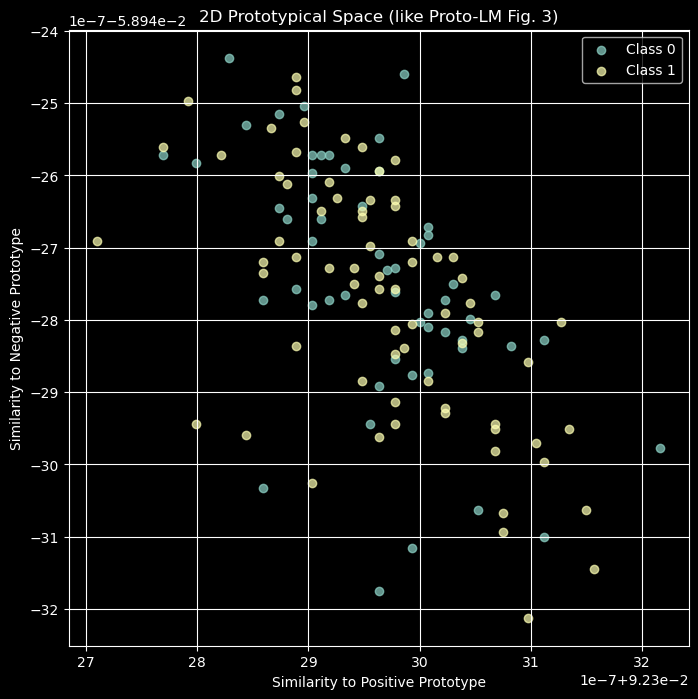

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# Get prototype vectors (concepts)
prototypes = proto.prototypes.detach().cpu().numpy()  # shape: (num_prototypes, hidden_dim)

# Get representations for some samples (e.g., from your test set)
batch = next(iter(drug_review_dm.test_dataloader()))
with torch.no_grad():
    # Get last hidden states for the batch
    llm_out = proto.LLM(
        input_ids=batch['input_ids'].to(proto.device),
        attention_mask=batch['attention_mask'].to(proto.device),
        output_hidden_states=True
    )
    sample_reps = llm_out.hidden_states[-1][:, 0, :].cpu().numpy()  # [CLS] token or mean pooling



# prototypes: (num_prototypes, hidden_dim)
# sample_reps: (batch_size, hidden_dim)
# Assume proto.prototype_class_vec exists and is (num_prototypes, num_classes)

# 1. Identify positive and negative prototypes
# If proto.prototype_class_vec is one-hot or softmax over classes:
proto_class = proto.prototype_class_vec.detach().cpu().numpy()  # (num_prototypes, num_classes)
positive_proto_idx = np.argmax(proto_class[:, 1])  # class 1 = positive
negative_proto_idx = np.argmax(proto_class[:, 0])  # class 0 = negative

positive_proto = torch.tensor(prototypes[positive_proto_idx])
negative_proto = torch.tensor(prototypes[negative_proto_idx])

# 2. Compute similarities for each sample
sample_vecs = torch.tensor(sample_reps)  # (batch_size, hidden_dim)
sim_pos = F.cosine_similarity(sample_vecs, positive_proto.unsqueeze(0), dim=1)
sim_neg = F.cosine_similarity(sample_vecs, negative_proto.unsqueeze(0), dim=1)

# 3. Get ground-truth labels for the batch
labels = batch['labels'].cpu().numpy()

# 4. Plot
plt.figure(figsize=(8, 8))
for label in np.unique(labels):
    idxs = np.where(labels == label)[0]
    plt.scatter(sim_pos[idxs], sim_neg[idxs], label=f"Class {label}", alpha=0.7)
plt.xlabel("Similarity to Positive Prototype")
plt.ylabel("Similarity to Negative Prototype")
plt.title("2D Prototypical Space (like Proto-LM Fig. 3)")
plt.legend()
plt.grid(True)
plt.show()

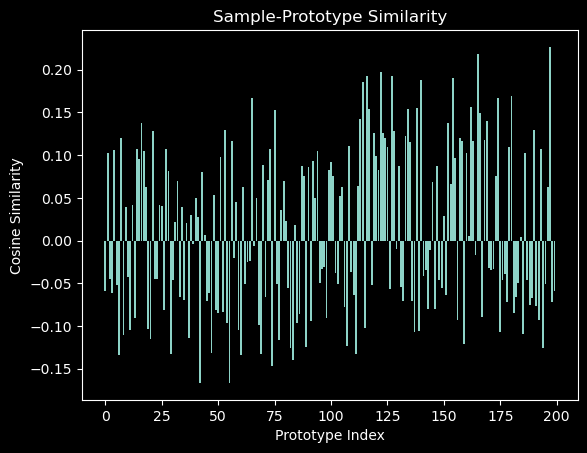

In [9]:
import torch.nn.functional as F

sample_vec = sample_reps[0]  # pick one sample
proto_vecs = torch.tensor(prototypes)
similarities = F.cosine_similarity(torch.tensor(sample_vec).unsqueeze(0), proto_vecs)
plt.bar(range(len(similarities)), similarities.numpy())
plt.xlabel("Prototype Index")
plt.ylabel("Cosine Similarity")
plt.title("Sample-Prototype Similarity")
plt.show()

In [13]:
import torch
import pandas as pd
import numpy as np
import torch.nn.functional as F

# 1. Get all review texts and their embeddings from the training set
train_dataset = drug_review_dm.dataset["train"]
all_texts = train_dataset["review"]

# Get all input_ids and attention_mask for the train set
input_ids = train_dataset["input_ids"]
attention_mask = train_dataset["attention_mask"]

# Compute all embeddings (CLS token)
all_embeddings = []
batch_size = 128
for i in range(0, len(input_ids), batch_size):
    batch_input_ids = input_ids[i:i+batch_size].to(proto.device)
    batch_attention_mask = attention_mask[i:i+batch_size].to(proto.device)
    with torch.no_grad():
        outputs = proto.LLM(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            output_hidden_states=True
        )
        batch_embeds = outputs.hidden_states[-1][:, 0, :].cpu()  # CLS token
        all_embeddings.append(batch_embeds)
all_embeddings = torch.cat(all_embeddings, dim=0)  # (num_samples, hidden_dim)

# 2. For each prototype, find the closest text
prototypes = proto.prototypes.detach().cpu()  # (num_prototypes, hidden_dim)
closest_texts = []
for proto_vec in prototypes:
    sims = F.cosine_similarity(all_embeddings, proto_vec.unsqueeze(0), dim=1)
    idx = torch.argmax(sims).item()
    closest_texts.append(all_texts[idx])

# 3. Save to CSV
df = pd.DataFrame({"prototype_index": range(len(closest_texts)), "closest_text": closest_texts})
df.to_csv("prototype_texts.csv", index=False)